# Introduction to Python and Jupyter Notebooks

This notebook introduces the basics of:
- Jupyter Notebooks
- Python programming
- Scientific Python tools

## What is a Jupyter Notebook?

A Jupyter Notebook is an interactive environment where you can combine:
- Code
- Text (Markdown)
- Visualizations

Notebooks are widely used in science because they allow you to:
- Document your workflow
- Explore data interactively
- Share reproducible analyses

## Scientific Question

In this notebook, we will explore a simple question:

**What can we learn about recent earthquakes from USGS data?**

To answer this, we will:
1. Learn basic Python
2. Use scientific tools
3. Analyze real earthquake data

# Python Primer

Before working with data, we need a few core Python concepts.

This is a short introduction to the essentials.

## Variables and Data Types

In [1]:
x = 10
y = 3.5
name = "EarthScope"

print(x, y, name)

10 3.5 EarthScope


### How it Works?

Let’s break this down step-by-step:

#### x = 10
- Python creates an **integer object** with value `10`
- The name `x` becomes a **reference** to that object

#### y = 3.5
- Python creates an **float object** with value `3.5`
- Same process, new object

#### name = "EarthScope"
- Python creates an **string object** with value `EarthScope`
- a string is an immutable sequence of Unicode characters used to store and manipulate text


## Data Types

Every object in Python has a **type**, which determines:
- What operations are allowed
- How it behaves in memory

In [2]:
type(x), type(y), type(name)

(int, float, str)

In [3]:
z = x + y

print(z)

13.5


#### `z = x + y`
Python:
1. Looks up `x` --> finds `10`
2. Looks up `y` --> finds `3.5`
3. Performs addition
4. Creates a new object `13.5`
5. Assigns it to `z`

#### `print(z)`
- Sends the value of `z` to output

> Key Idea: Variables are **labels pointing to objects**, not containers

### Exercise: Predict Before Running

What will this print?

In [4]:
a = 3
b = a
a = 10

print(b)

3


### Explanation

- b = a does **not copy the value**, it copies the **reference**
- When `a` is reassigned, `b` still points to the original object 3

This is foundational to understanding Python behavior later

## Lists

Lists allow us to store collections of values.

Indexing lets us access individual elements. Python uses **zero-based indexing**, so the first element is index 0.

In [5]:
numbers = [1, 2, 3, 4, 5]

print(numbers)
print(numbers[0])
print(numbers[-1])

[1, 2, 3, 4, 5]
1
5


### Indexing

- data[0] --> first element
- data[-1] --> last element

Python:
- Finds the memory location of the list
- Computes the offset
- Returns the referenced object
- [Lists and memory allocation](https://www.geeksforgeeks.org/python/memory-management-in-lists-and-tuples-using-python/)

### Exercise: Slicing

What does this return?

Consider your response before running the cell

In [6]:
values = [10, 20, 30, 40]

print(values[1:3])

[20, 30]


### How it Works

Slicing format:
[start : end]

- Start is **included**
- End is **excluded** This can be a sticking point for many developers

So:
- values[1:3] → [20, 30]

## Dictionaries

[ANMO Station](https://earthquake.usgs.gov/monitoring/operations/stations/IU/ANMO/)

In [7]:
station = {
    "name": "ANMO",
    "latitude": 34.95,
    "longitude": -106.46
}

print(station["name"])

ANMO


## Control Flow

In [8]:
value = 7

if value > 5:
    print("Greater than 5")
else:
    print("5 or less")

Greater than 5


In [9]:
for n in numbers: #See numbers list above
    print(n)

1
2
3
4
5


### What Python is Doing

1. Creates an iterator from the list
2. Repeats:
   - Assign next value to value
   - Run the indented block


### Indentation Matters

- Indentation defines structure in Python
- Python is whitespace sensitive
- Unlike languages like C, Java, or JavaScript that rely on curly braces {} to group code, Python uses indentation levels

## Functions

In [10]:
def square(x):
    return x * x

square(4)

16

### What Happens During a Function Call

- A new **local scope** is created
- `x` is assigned the input value
- Code runs
- Result is returned

Functions isolate logic

In [11]:
for i in range(3):
    print(i)

print("done")

0
1
2
done


- Only the indented lines are inside the loop
- `"done"` runs after the loop finishes

# Scientific Python Tools

Now we introduce tools used in scientific computing:
- NumPy (numerical arrays)
- Pandas (tabular data)
- Matplotlib (visualization)

### Notebook Setup

We import commonly used scientific libraries:

- **NumPy**: numerical operations
- **pandas**: tabular data analysis
- **matplotlib**: visualization

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## NumPy Example

In [13]:
data = np.array([1, 2, 3, 4, 5])

np.mean(data), np.std(data)

(np.float64(3.0), np.float64(1.4142135623730951))

### Why This is Useful

Unlike lists:
- Arrays store data in **contiguous memory**
- Operations are implemented in **fast compiled code**

When you do:
```python
arr = np.array([1, 2, 3])
print(arr * 2)
```
arr * 2

NumPy:
- Applies the operation to every element
- Does this without a Python loop

This is called **vectorization**


## Pandas Example

In [14]:
df_example = pd.DataFrame({
    "station": ["ANMO", "BOZ", "COLA"],
    "latitude": [34.95, 45.78, 64.87],
    "longitude": [-106.46, -111.04, -147.86]
})

df_example

,station,latitude,longitude
0,ANMO,34.95,-106.46
1,BOZ,45.78,-111.04
2,COLA,64.87,-147.86


### What a DataFrame Is

- A collection of labeled columns
- Each column is a NumPy array

## Simple Plot

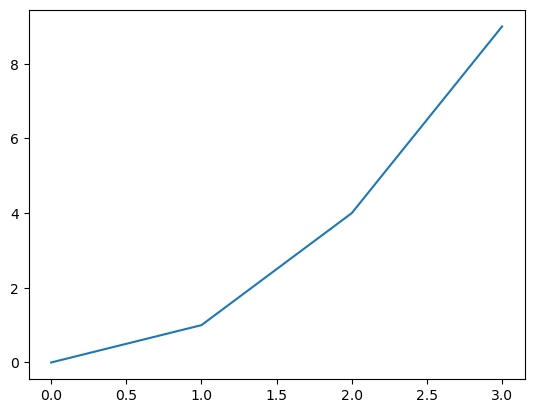

In [15]:
x = [0, 1, 2, 3]
y = [0, 1, 4, 9]

plt.plot(x, y)
plt.show()

### How Plotting Works

- `plt.plot()` stores instructions
- `plt.show()` renders the figure

## Working with Real Data

In practice, scientific data is usually stored in CSV tables (comma separated values). We use **pandas** to work with this type of data.

In [16]:
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

df = pd.read_csv(url)

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-07-18T17:56:50.927Z,31.665000,-104.396000,8.273,1.60,ml,17.0,70.0,0.000000,0.40,...,2026-07-18T18:01:04.012Z,"56 km S of Whites City, New Mexico",earthquake,0.00,2.69719,0.200,13.0,automatic,tx,tx
1,2026-07-18T17:51:03.742Z,58.720000,-152.886000,48.600,1.70,ml,9.0,128.0,0.300000,0.80,...,2026-07-18T17:52:35.125Z,"73 km N of Aleneva, Alaska",earthquake,9.00,7.66670,0.800,4.0,automatic,ak,ak
2,2026-07-18T17:44:55.280Z,38.767334,-122.735336,0.120,1.09,md,8.0,154.0,0.009996,0.03,...,2026-07-18T17:46:30.161Z,"2 km ESE of The Geysers, CA",earthquake,0.37,0.67000,0.050,8.0,automatic,nc,nc
3,2026-07-18T17:30:48.760Z,31.494000,-104.293000,0.000,1.60,ml,6.0,148.0,0.200000,0.90,...,2026-07-18T18:00:32.639Z,"51 km WNW of Toyah, Texas",earthquake,0.00,NaN,0.400,6.0,automatic,tx,tx
4,2026-07-18T17:26:25.879Z,14.239200,-92.880500,10.000,5.70,mww,84.0,141.0,3.027000,0.86,...,2026-07-18T17:54:01.418Z,"72 km SW of Puerto Madero, Mexico",earthquake,5.98,1.77000,0.052,36.0,reviewed,us,us


### Loading Data from a URL

| Code Segment | What it does |
|---|---|
| url = "..." | Stores the web address as a variable |
| pd.read_csv(url) | Downloads the CSV and converts it to a DataFrame |
| df.head() | Previews the first 5 rows |


- Step 1: Store the URL
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

- Step 2: Load it into a DataFrame
df = pd.read_csv(url)

- Step 3: Preview the data
df.head()        # first 5 rows (default)
df.head(10)      # first 10 rows

**Notes**
  - **Remember:** import pandas as pd must be run before this works!
  - **Tip:** df is just a convention it stands for DataFrame

## Inspecting the Dataset

Let's explore the structure of the dataset.

Questions to consider:
- What columns are present?
- What does each column represent?

In [17]:
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')

In [18]:
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,10629.000000,10629.000000,10629.000000,10628.00000,10618.000000,10617.000000,10614.000000,10617.000000,10424.000000,10547.000000,10594.000000,10627.000000
mean,39.752365,-110.348609,21.577668,1.65045,25.301469,118.166293,0.559847,0.304707,3.398167,2.739784,0.180942,19.327185
std,17.596647,74.868566,49.381154,1.23948,22.570681,71.767377,1.938702,0.287800,6.464259,4.953878,0.099997,31.709395
min,-62.112500,-179.951000,-3.170000,-1.34000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.407167,-152.729333,3.800000,0.83000,11.000000,64.000000,0.027862,0.100000,0.290000,0.520000,0.100000,7.000000
50%,38.819168,-122.736504,8.056600,1.48500,19.000000,94.000000,0.085575,0.193800,0.682554,1.024543,0.172061,12.000000
75%,52.700000,-112.874167,15.900000,2.10000,32.000000,158.000000,0.300000,0.500000,4.200000,2.735300,0.214886,20.000000
max,78.412500,179.999100,676.469000,7.50000,299.000000,350.000000,42.241000,2.600000,99.000000,75.406100,2.400000,792.000000


### Exploring Your DataFrame

| Command | What it does |
|---|---|
| df.columns | Lists all column names |
| df.describe() | Summary statistics for numeric columns |
| df.describe(include='all') | Summary stats including text columns |

- See all column names
df.columns

- Get summary statistics (numeric columns only)
df.describe()

- Get summary statistics (ALL columns)
df.describe(include='all')

| describe() stat | Meaning |
|---|---|
| count | Number of non-empty values |
| mean | Average |
| std | How spread out the values are |
| min / max | Smallest / largest value |
| 25% / 50% / 75% | Where the middle of your data lives |



## Exploring the Data

We now begin asking simple questions about the dataset.

In [19]:
# Maximum magnitude
df["mag"].max()

7.5

### Selecting a Column and Aggregating

Grab one column and find the max
df["magnitude"].max()

**Try it**
Swap out .max() for other aggregations
- df["mag"].min()
- df["mag"].mean()
- df["mag"].sum()
- df["mag"].count()

In [20]:
# Count earthquakes above magnitude 4
df[df["mag"] > 4].shape[0]

916

### Filtering Rows and Counting Results

| Piece | What it does |
|---|---|
| df["col"] > 4 | Creates a True/False mask for each row |
| df[condition] | Keeps only rows where condition is True |
| .shape | Returns (rows, columns) as a pair |
| .shape[0] | Grabs just the row count |


- Count rows where magnitude is greater than 4
- df[df["magnitude"] > 4].shape[0]

- Comparison operators you can use
df[df["magnitude"] > 4]    # greater than
df[df["magnitude"] < 2]    # less than
df[df["magnitude"] == 4]   # exactly equal to
df[df["magnitude"] >= 4]   # greater than or equal to
df[df["magnitude"] != 4]   # not equal to


**Note:** .shape returns **(rows, columns)** add [0] to get just the row count


### Magnitude Reflection

What do these values tell us?

- Are large earthquakes common or rare?
- How might this affect hazard assessment?

## Visualizing the Data

Visualization helps us identify patterns that are not obvious from raw numbers.

Text(0.5, 1.0, 'Distribution of Earthquake Magnitudes')

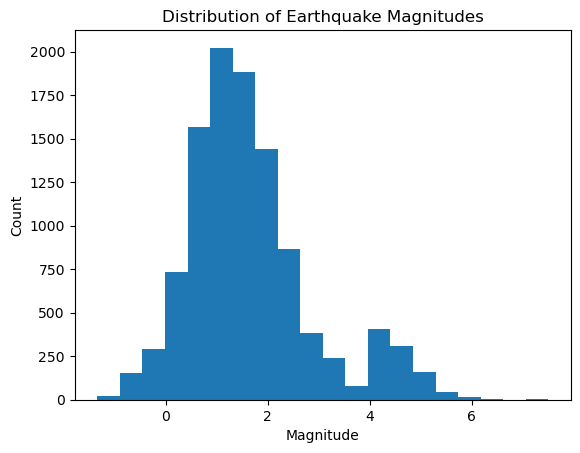

In [21]:
plt.hist(df["mag"], bins=20)
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.title("Distribution of Earthquake Magnitudes")

This histogram shows the distribution of earthquake magnitudes.

Typically, we observe:
- Many small earthquakes
- Few large earthquakes

Is this pattern what you expected? 

Text(0.5, 1.0, 'Earthquake Magnitudes Over Time')

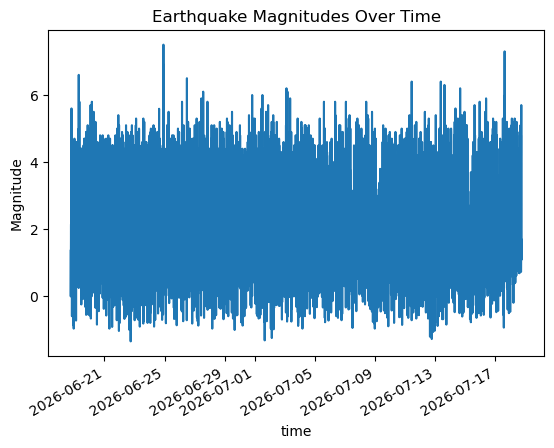

In [22]:
df["time"] = pd.to_datetime(df["time"])
df.set_index("time")["mag"].plot()
plt.ylabel("Magnitude")
plt.title("Earthquake Magnitudes Over Time")

## Exercises

Now it's your turn to explore the dataset.

### Exercise 1: Basic Statistics

Find:
- The minimum magnitude
- The average magnitude

### Exercise 2: Filtering Data

Create a new DataFrame containing only earthquakes with magnitude greater than 5.

### Exercise 3: Visualization

Create:
- A histogram of earthquake depth
- A scatter plot of magnitude vs depth
- - Note [matplotlib plot type documentation](https://matplotlib.org/stable/plot_types/index.html)

### Exercise 4: Interpretation

Based on your plots:
- Do you observe any relationship between depth and magnitude?
- What might explain this?

## Mini Project

Using everything you’ve learned:

1. Explore the dataset
2. Create at least two meaningful plots
3. Write 2–3 sentences describing your findings

Focus on clarity and scientific reasoning.

## Summary

In this notebook, you learned how to:

- Structure a scientific notebook
- Use Python for data exploration
- Analyze tabular data with pandas
- Visualize results with matplotlib

Most importantly, you practiced thinking about data like a scientist.

#### Ceasar Cipher

*(stolen from http://www.ling.gu.se/~lager/python_exercises.html)*

In cryptography, a Caesar cipher is a very simple encryption techniques in which each letter in the plain text is replaced by a letter some fixed number of positions down the alphabet. For example, with a shift of 3, A would be replaced by D, B would become E, and so on. The method is named after Julius Caesar, who used it to communicate with his generals. ROT-13 ("rotate by 13 places") is a widely used example of a Caesar cipher where the shift is 13. In Python, the key for ROT-13 may be represented by means of the following dictionary:

```python
key = {'a':'n', 'b':'o', 'c':'p', 'd':'q', 'e':'r', 'f':'s', 'g':'t', 'h':'u',
       'i':'v', 'j':'w', 'k':'x', 'l':'y', 'm':'z', 'n':'a', 'o':'b', 'p':'c',
       'q':'d', 'r':'e', 's':'f', 't':'g', 'u':'h', 'v':'i', 'w':'j', 'x':'k',
       'y':'l', 'z':'m', 'A':'N', 'B':'O', 'C':'P', 'D':'Q', 'E':'R', 'F':'S',
       'G':'T', 'H':'U', 'I':'V', 'J':'W', 'K':'X', 'L':'Y', 'M':'Z', 'N':'A',
       'O':'B', 'P':'C', 'Q':'D', 'R':'E', 'S':'F', 'T':'G', 'U':'H', 'V':'I',
       'W':'J', 'X':'K', 'Y':'L', 'Z':'M'}
```

Your task in this exercise is to implement an decoder of ROT-13. Once you're done, you will be able to read the following secret message:

```
Pnrfne pvcure? V zhpu cersre Pnrfne fnynq!
```

**BONUS:** Write an encoder!